In [1]:
#Milestone 1: Data Collection
import requests
import pandas as pd
api = '72201e1449c18936bad459c7d33f73db'
url = 'https://api.themoviedb.org/3/discover/movie'
def fetch_movie_data(page=1):
    params = {
        'api_key': api,
        'page': page,
        'sort_by': 'popularity.desc', 
        'language': 'en-US',  
    }
    response = requests.get(url, params=params)
    if response.status_code != 200:
        return []
        
    data = response.json()
    if 'results' in data:
        return data['results']
    else:
        return []
movies_data = []
pages_needed =100 
for page in range(1, pages_needed + 1):
    movies = fetch_movie_data(page)
    if not movies:
        continue
    for movie in movies:
        if isinstance(movie, dict):
            movie_data = {
                'Title': movie.get('title'),
                'Genre(s)': ', '.join([str(genre) for genre in movie.get('genre_ids', [])]),  
                'Release Year': movie.get('release_date', '').split('-')[0] if movie.get('release_date') else 'N/A',  
                'IMDB Rating': movie.get('vote_average'),
                'Votes': movie.get('vote_count'),
                'Description': movie.get('overview'),
                'Poster URL': f"https://image.tmdb.org/t/p/w500{movie.get('poster_path')}" if movie.get('poster_path') else None
            }
            movies_data.append(movie_data)
df = pd.DataFrame(movies_data)
df.to_csv('movies_dataset.csv', index=False)
df

,Title,Genre(s),Release Year,IMDB Rating,Votes,Description,Poster URL
0,Your Heart Will Be Broken,"10749, 18",2026,6.520,50,High school student Polina is saved from bully...,https://image.tmdb.org/t/p/w500/7wIBfBl2gejt6x...
1,Avatar: Fire and Ash,"878, 12, 14",2025,7.370,2436,In the wake of the devastating war against the...,https://image.tmdb.org/t/p/w500/bRBeSHfGHwkEpI...
2,Hoppers,"16, 10751, 878, 35, 12",2026,7.600,415,Scientists have discovered how to 'hop' human ...,https://image.tmdb.org/t/p/w500/xjtWQ2CL1mpmMN...
3,Crime 101,"80, 53",2026,7.044,555,When an elusive thief whose high-stakes heists...,https://image.tmdb.org/t/p/w500/tVvpFIoteRHNno...
4,Shelter,"28, 80, 53",2026,6.800,498,A man living in self-imposed exile on a remote...,https://image.tmdb.org/t/p/w500/buPFnHZ3xQy6vZ...
...,...,...,...,...,...,...,...
1995,Hole-in-law,10749,2020,5.500,12,An omnibus movie about the jealousy of a man w...,https://image.tmdb.org/t/p/w500/ZAhAOX5Rsstfrb...
1996,Blue Beetle,"28, 878, 12",2023,6.638,3055,Recent college grad Jaime Reyes returns home f...,https://image.tmdb.org/t/p/w500/mXLOHHc1Zeuwsl...
1997,Vanilla Sky,"9648, 10749, 878",2001,6.821,4600,"David Aames has it all: wealth, good looks and...",https://image.tmdb.org/t/p/w500/cAh2pCiNPftsY3...
1998,Ko Ga Loak Village,"35, 27",2025,3.800,5,"A wave of chilling serial murders emerges, mar...",https://image.tmdb.org/t/p/w500/jt31qZw5W1RFXf...


In [2]:
#Milestone 2: Data Cleaning and Preprocessing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('movies_dataset.csv')
#Handle missing values
print("Handle missing values:")
print(df.isnull().sum())
df['IMDB Rating'] = df['IMDB Rating'].fillna(df['IMDB Rating'].mean())  
df['Votes'] = df['Votes'].fillna(df['Votes'].mean())  
df['Description'] = df['Description'].fillna('No Description')  
df['Genre(s)'] = df['Genre(s)'].fillna('Unknown') 
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())
df['Poster URL'] = df['Poster URL'].fillna('No Poster')
numerical_columns = ['IMDB Rating', 'Votes']
#Normalize data
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
#Convert categorical features
genres_encoded = df['Genre(s)'].str.get_dummies(sep=', ').add_prefix('Genre_')
df = pd.concat([df, genres_encoded], axis=1)
#Remove duplicate entries.
df.drop_duplicates(inplace=True)
df.to_csv('movies_dataset_cleaned.csv', index=False)
df

Handle missing values:
Title            0
Genre(s)        12
Release Year     0
IMDB Rating      0
Votes            0
Description     10
Poster URL       2
dtype: int64


,Title,Genre(s),Release Year,IMDB Rating,Votes,Description,Poster URL,Genre_10402,Genre_10749,Genre_10751,...,Genre_28,Genre_35,Genre_36,Genre_37,Genre_53,Genre_80,Genre_878,Genre_9648,Genre_99,Genre_Unknown
0,Your Heart Will Be Broken,"10749, 18",2026,-0.144785,-0.859613,High school student Polina is saved from bully...,https://image.tmdb.org/t/p/w500/7wIBfBl2gejt6x...,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,Avatar: Fire and Ash,"878, 12, 14",2025,0.442489,-0.463969,In the wake of the devastating war against the...,https://image.tmdb.org/t/p/w500/bRBeSHfGHwkEpI...,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,Hoppers,"16, 10751, 878, 35, 12",2026,0.601398,-0.799089,Scientists have discovered how to 'hop' human ...,https://image.tmdb.org/t/p/w500/xjtWQ2CL1mpmMN...,0,0,1,...,0,1,0,0,0,0,1,0,0,0
3,Crime 101,"80, 53",2026,0.217252,-0.775874,When an elusive thief whose high-stakes heists...,https://image.tmdb.org/t/p/w500/tVvpFIoteRHNno...,0,0,0,...,0,0,0,0,1,1,0,0,0,0
4,Shelter,"28, 80, 53",2026,0.048670,-0.785326,A man living in self-imposed exile on a remote...,https://image.tmdb.org/t/p/w500/buPFnHZ3xQy6vZ...,0,0,0,...,1,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,Hole-in-law,10749,2020,-0.849513,-0.865914,An omnibus movie about the jealousy of a man w...,https://image.tmdb.org/t/p/w500/ZAhAOX5Rsstfrb...,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1996,Blue Beetle,"28, 878, 12",2023,-0.063257,-0.361327,Recent college grad Jaime Reyes returns home f...,https://image.tmdb.org/t/p/w500/mXLOHHc1Zeuwsl...,0,0,0,...,1,0,0,0,0,0,1,0,0,0
1997,Vanilla Sky,"9648, 10749, 878",2001,0.063179,-0.105137,"David Aames has it all: wealth, good looks and...",https://image.tmdb.org/t/p/w500/cAh2pCiNPftsY3...,0,1,0,...,0,0,0,0,0,0,1,1,0,0
1998,Ko Ga Loak Village,"35, 27",2025,-2.024059,-0.867075,"A wave of chilling serial murders emerges, mar...",https://image.tmdb.org/t/p/w500/jt31qZw5W1RFXf...,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [3]:
#Milestone 3: Exploratory Data Analysis (EDA)
#Perform statistical analysis on the dataset (e.g., mean, median, distribution of ratings)
print("Statistical analysis on the dataset:")
df.describe()

Statistical analysis on the dataset:


,Release Year,IMDB Rating,Votes,Genre_10402,Genre_10749,Genre_10751,Genre_10752,Genre_10770,Genre_12,Genre_14,...,Genre_28,Genre_35,Genre_36,Genre_37,Genre_53,Genre_80,Genre_878,Genre_9648,Genre_99,Genre_Unknown
count,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,...,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000
mean,2010.822365,0.005233,0.014159,0.021937,0.139112,0.132691,0.032103,0.004280,0.263777,0.157303,...,0.354200,0.250401,0.039058,0.012306,0.262707,0.134296,0.188871,0.072231,0.010166,0.005886
std,16.178194,1.000184,1.017683,0.146517,0.346156,0.339332,0.176320,0.065302,0.440798,0.364184,...,0.478398,0.433360,0.193786,0.110277,0.440223,0.341062,0.391511,0.258940,0.100339,0.076511
min,1910.000000,-4.649516,-0.867904,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.000000,-0.280894,-0.816997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016.000000,0.186852,-0.284056,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2024.000000,0.540598,0.420840,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2028.000000,2.259581,5.650601,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


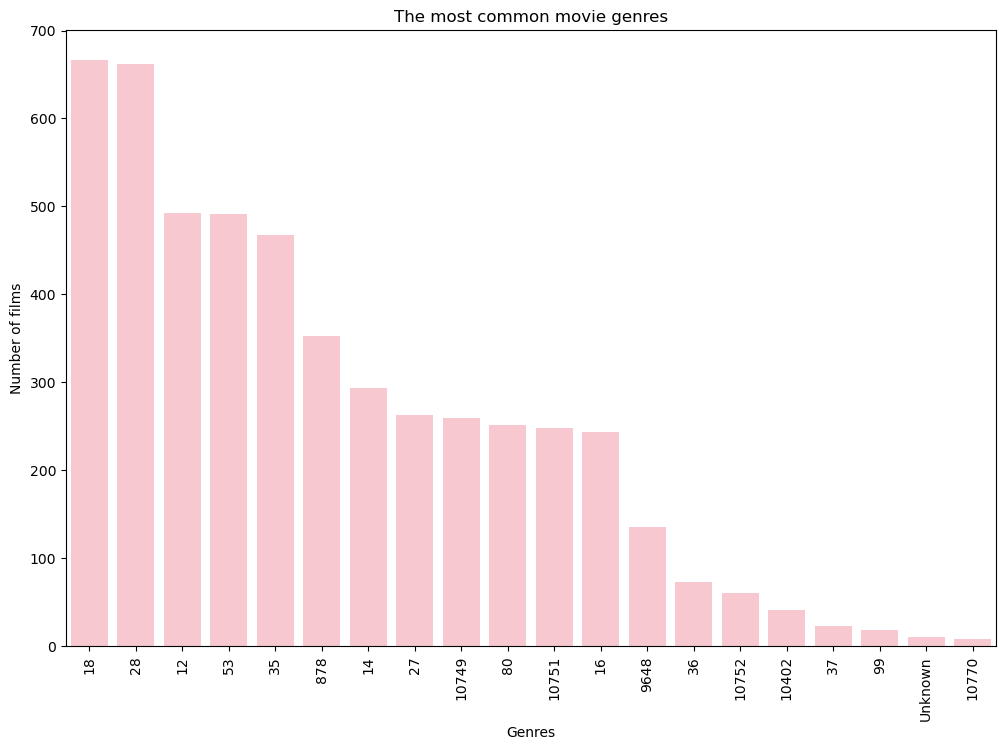

In [4]:
#The most common movie genres
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
genre_counts = df['Genre(s)'].str.split(', ').explode().value_counts()
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.index, y=genre_counts.values,color='pink')
plt.xticks(rotation=90)
plt.title('The most common movie genres')
plt.xlabel('Genres')
plt.ylabel('Number of films')
plt.show()

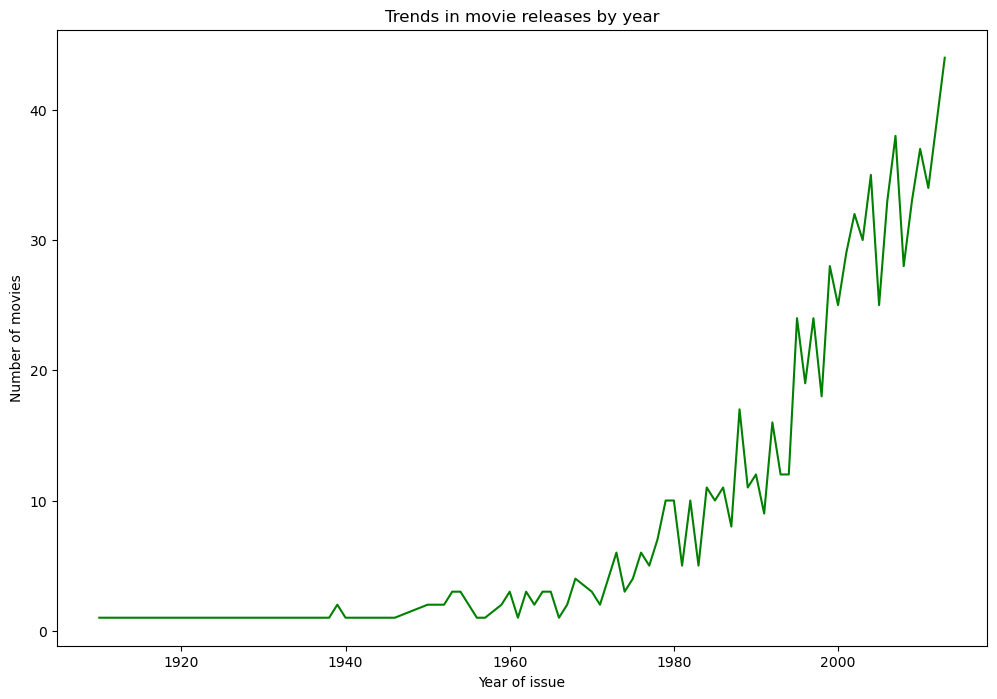

In [5]:
#Trends in movie releases over time.
release_year_counts = df['Release Year'].value_counts().sort_index().head(70)
plt.figure(figsize=(12, 8))
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values,color='green')
plt.title('Trends in movie releases by year')
plt.xlabel('Year of issue')
plt.ylabel('Number of movies')
plt.show()


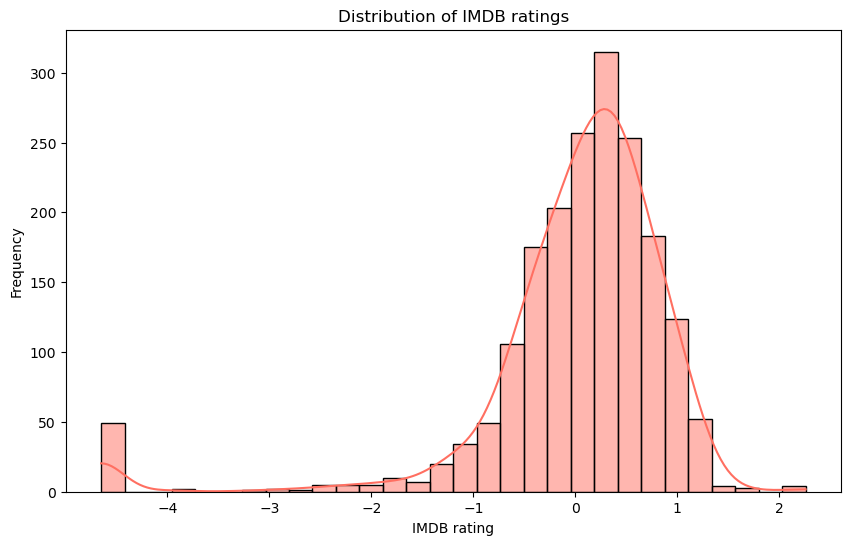

In [6]:
#Distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['IMDB Rating'], kde=True, bins=30,color='#ff6f61')
plt.title('Distribution of IMDB ratings')
plt.xlabel('IMDB rating')
plt.ylabel('Frequency')
plt.show()

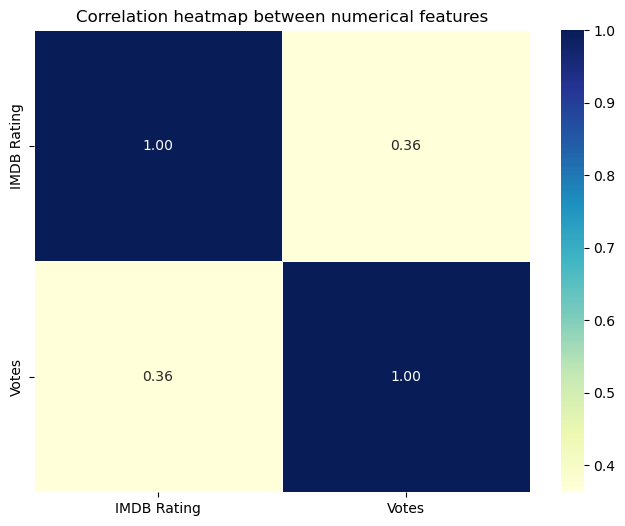

In [7]:
#Correlation heatmap between numerical features
correlation_matrix = df[['IMDB Rating', 'Votes']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)  
plt.title('Correlation heatmap between numerical features')
plt.show()


In [8]:
#Milestone 4: Linear Regression Model for Rating Prediction
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv('movies_dataset_cleaned.csv')
df['Genre(s)'] = df['Genre(s)'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])
all_genres = set([genre for genres in df['Genre(s)'] for genre in genres])
for genre in all_genres:
    df[f"Genre_{genre}"] = df['Genre(s)'].apply(lambda x: 1 if genre in x else 0)
df.drop(columns=['Genre(s)'], inplace=True) 
X = df.drop(columns=['IMDB Rating', 'Title', 'Description', 'Poster URL'])
y = df['IMDB Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R² score: {r2:.3f}")

MAE: 0.504
RMSE: 0.842
R² score: 0.213


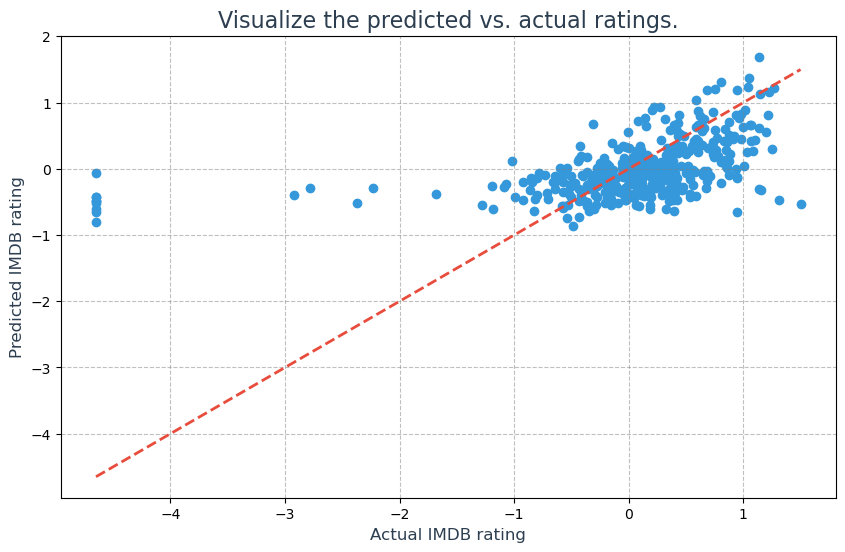

In [9]:
#Visualize the predicted vs. actual ratings.
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=1, color='#3498db')  
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='#e74c3c', linestyle='--', linewidth=2)
plt.title('Visualize the predicted vs. actual ratings.', fontsize=16, color='#2c3e50')  
plt.xlabel('Actual IMDB rating', fontsize=12, color='#2c3e50')  
plt.ylabel('Predicted IMDB rating', fontsize=12, color='#2c3e50')  
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.show()

In [10]:
#Milestone 5: Building a Simple Recommendation System
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
df = pd.read_csv('movies_dataset_cleaned.csv')
df['Genre(s)'] = df['Genre(s)'].apply(lambda x: x.replace(', ', ' '))
df['Content'] = df['Description'] + ' ' + df['Genre(s)']
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Content'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend_movies(movie_title, cosine_sim=cosine_sim):
    idx = df[df['Title'] == movie_title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df['Title'].iloc[movie_indices]
movie = 'Moana'  
recommended_movies = recommend_movies(movie)
print(f"If you like '{movie}', you might also like:")
for idx, movie in enumerate(recommended_movies, 1):
    print(f"{idx}. {movie}")

If you like 'Moana', you might also like:
1. Moana 2
2. Finding Nemo
3. Outcome
4. Miraculous World: London, At the Edge of Time
5. Send Help
6. The Menu
7. Manchester by the Sea
8. Manchester by the Sea
9. Kong: Skull Island
10. Miss Peregrine's Home for Peculiar Children


In [11]:
#Milestone 6: Data Storage and Access
import sqlite3
conn = sqlite3.connect('movies.db')
cursor = conn.cursor()
cursor.execute('DROP TABLE IF EXISTS movies')
cursor.execute('''
CREATE TABLE movies (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    genre TEXT,
    release_year INTEGER,
    imdb_rating REAL,
    votes INTEGER,
    description TEXT,
    poster_url TEXT
)
''')
df = pd.read_csv('movies_dataset_cleaned.csv')
movies_data = [
    (row['Title'], row['Genre(s)'], row['Release Year'], row['IMDB Rating'], row['Votes'], row['Description'], row['Poster URL'])
    for index, row in df.iterrows()
]

cursor.executemany('''
INSERT INTO movies (title, genre, release_year, imdb_rating, votes, description, poster_url)
VALUES (?, ?, ?, ?, ?, ?, ?)
''', movies_data)
conn.commit()
def get_all_movies():
    cursor.execute("SELECT * FROM movies")
    return cursor.fetchall()
all_movies = get_all_movies()
for movie in all_movies:
    print(movie)
conn.close()

(1, 'Your Heart Will Be Broken', '10749, 18', 2026, -0.1447846170573173, -0.8596127990560092, 'High school student Polina is saved from bullying at her new school and makes a deal with the main bully Bars: he must pretend to be her boyfriend and protect her, and she must do everything he says. During this game, the couple develops real feelings, but her family and classmates have reasons to separate the lovers.', 'https://image.tmdb.org/t/p/w500/7wIBfBl2gejt6xHxNSK0reVIm7E.jpg')
(2, 'Avatar: Fire and Ash', '878, 12, 14', 2025, 0.4424886218959935, -0.4639690209950176, "In the wake of the devastating war against the RDA and the loss of their eldest son, Jake Sully and Neytiri face a new threat on Pandora: the Ash People, a violent and power-hungry Na'vi tribe led by the ruthless Varang. Jake's family must fight for their survival and the future of Pandora in a conflict that pushes them to their emotional and physical limits.", 'https://image.tmdb.org/t/p/w500/bRBeSHfGHwkEpImlhxPmOcUsaeg.

In [12]:
pip install streamlit


Note: you may need to restart the kernel to use updated packages.


In [13]:
#Milestone 7: Interactive Interface for Recommendations (Optional)
import sqlite3
import pandas as pd
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
def load_movies():
    conn = sqlite3.connect('movies.db') 
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM movies")
    movies = cursor.fetchall()
    conn.close()
    columns = ["id", "title", "genre", "release_year", "imdb_rating", "votes", "description", "poster_url"]
    df = pd.DataFrame(movies, columns=columns)
    return df
def preprocess_data(df):
    df['release_year'] = df['release_year'].fillna('').astype(str)
    df['votes'] = df['votes'].fillna(0).astype(int).astype(str)
    df['imdb_rating'] = df['imdb_rating'].fillna(0).astype(float).astype(str)
    df['Content'] = (df['description'].fillna('') + ' ' +
                     df['release_year'] + ' ' +
                     df['votes'] + ' ' +
                     df['imdb_rating'] + ' ' +
                     df['genre'].fillna(''))
    return df

def recommend_movies(df, selected_movie, top_n=5):
    selected_content = df.loc[df['title'] == selected_movie, 'Content'].iloc[0]
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(df['Content'].tolist() + [selected_content])
    cosine_similarities = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()
    df['similarity'] = cosine_similarities
    recommendations = df.sort_values(by='similarity', ascending=False).head(top_n)
    return recommendations[['title', 'release_year', 'votes', 'imdb_rating', 'similarity', 'poster_url']]
st.set_page_config(page_title="Movie recommendation system from Makhabbat,Nurila,Zhaniya✨🥰", layout="wide", page_icon="🎥")
st.title("Movie recommendation system from Makhabbat,Nurila,Zhaniya✨🥰")
st.write("Find the perfect movie just for you based on your unique tastes! 🎬✨ Let's discover some fun recommendations together! 🌟😊")
df = load_movies()
preprocessed_df = preprocess_data(df)
st.sidebar.header("User Options")
st.sidebar.write("Pick a movie you love, and we'll suggest some perfect recommendations just for you! 💖🍿🎥")
selected_movie = st.sidebar.selectbox("🎬 Choose a movie you like:", preprocessed_df['title'].tolist())
if selected_movie:
    st.subheader(f"🎥 Recommendations for: {selected_movie}")
    recommendations = recommend_movies(preprocessed_df, selected_movie)
    for _, row in recommendations.iterrows():
        st.markdown("---")
        col1, col2 = st.columns([1, 4])
        with col1:
            st.image(row['poster_url'], width=120, caption=row['title'])
        with col2:
            st.text(f"Title: {row['title']}")
            st.text(f"Year: {row['release_year']}")
            st.text(f"Votes: {row['votes']}")
            st.text(f"IMDB Rating: {row['imdb_rating']}")
            st.text(f"Similarity Score: {row['similarity']:.2f}")
            

2026-04-09 01:44:33.099 
  command:

    streamlit run C:\Users\ilash\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
